In [1]:
from pathlib import Path
import os
import sys

_here = Path.cwd().resolve()
_repo_root = next(path for path in (_here, *_here.parents) if (path / "configs" / "cfg.py").exists())
os.chdir(_repo_root)
sys.path.insert(0, str(_repo_root))

import matplotlib.pyplot as plt
import pandas as pd
from pprint import pprint
from IPython.display import Image, Markdown, display

from data.share_data import load_share_data
from scripts.madrl import SCHEMES, plot_madrl_outputs, run_madrl_scheme_experiment
from utils.run_artifacts import load_experiment_context


In [2]:
run_dir = Path("artifacts/runs/20260512_220936_494b4c57")
scheme_name = "madrl_base"
cfg, run_dir = load_experiment_context(run_dir)
share_data = load_share_data(run_dir / "share_data", cfg)
assert int(share_data.manifest["sequence_length"]) == int(cfg.obs.sequence_length)
spec = next(item for item in SCHEMES if item["scheme"] == scheme_name)
train_episodes = 20 #7天的时候是500
w_voltage, w_line, w_trafo = spec["reward"]

display(Markdown("# MADRL + No Safety + LSTM Forecast"))
display(pd.DataFrame([{
    "run_dir": str(run_dir),
    "scheme": scheme_name,
    "controller": spec["controller"],
    "train_episodes": train_episodes,
    "device": cfg.runtime.device,
    "train_window_days": int(cfg.env.train_window_days),
    "train_episode_steps": int(cfg.env.episode_steps) * int(cfg.env.train_window_days),
    "action_dim": int(cfg.model.action_dim),
    "max_charge_rate": float(cfg.env.max_charge_rate),
    "init_soc": float(cfg.env.init_soc),
    "train_init_soc_low": float(cfg.env.train_init_soc_low),
    "train_init_soc_high": float(cfg.env.train_init_soc_high),
    "batch_size": int(cfg.train.batch_size),
    "gamma": float(cfg.algo.gamma),
    "tau": float(cfg.algo.tau),
    "hidden_dim": int(cfg.model.hidden_dim),
    "n_step_return": int(cfg.train.n_step_return),
    "w_voltage_pen": float(w_voltage),
    "w_line_pen": float(w_line),
    "w_trafo_pen": float(w_trafo),
}]))


# MADRL + No Safety + LSTM Forecast

,run_dir,scheme,controller,train_episodes,device,train_window_days,train_episode_steps,action_dim,max_charge_rate,init_soc,train_init_soc_low,train_init_soc_high,batch_size,gamma,tau,hidden_dim,n_step_return,w_voltage_pen,w_line_pen,w_trafo_pen
0,artifacts\runs\20260512_220936_494b4c57,madrl_base,MADRL_BASE,20,cuda,2,192,2,0.5,0.05,0.05,0.05,128,0.999,0.01,256,48,0.0,0.0,0.0


In [3]:
result = run_madrl_scheme_experiment(cfg, run_dir, share_data, spec, episodes=train_episodes)

display(Markdown("## Train Summary"))
display(result["train_summary"])

saved = result["records"][scheme_name]
display(Markdown("## Test Metrics"))
display(saved["metrics_df"])
display(Markdown("## Agent Summary"))
display(saved["rollout"].summary)
pprint({"record_dir": str(saved["record_dir"])})


train madrl_base:   0%|          | 0/20 [00:00<?, ?episode/s]

MADRL + No Safety + LSTM Forecast/lstm:   0%|          | 0/15 [00:00<?, ?episode/s]

## Train Summary

,scheme,controller,label,algo,projection,episodes,steps,updates,elapsed_s,vec_env_kind,...,action_sample_s,env_step_s,replay_add_s,sample_update_s,other_s,batch_size,num_envs,parallel_episode_sampling,model_path,record_dir
0,madrl_base,MADRL_BASE,MADRL + No Safety + LSTM Forecast,MATD3,False,20,3840,2305,265.756494,subproc,...,17.20734,170.701439,0.633445,75.461807,1.752464,128,1,unique_active,artifacts\runs\20260512_220936_494b4c57\models...,artifacts\runs\20260512_220936_494b4c57\result...


## Test Metrics

,controller,soc_mode,storage_charge_cost_total_eur,storage_discharge_revenue_total_eur,storage_profit_total_eur,storage_objective_total_eur,system_other_cost_eur,total_eur,soc_penalty_total,voltage_penalty_total,...,voltage_step_delta_p95_pu,voltage_step_delta_max_pu,voltage_spread_mean_pu,voltage_spread_max_pu,trafo_overload_steps,trafo_loading_max_pct,feeder_netload_ramp_mean_abs_kw,feeder_netload_ramp_max_kw,battery_net_power_kw_mean_abs,returned_primary_objective_eur
0,MADRL + No Safety + LSTM Forecast,continuous,696.081595,673.553472,-22.528123,22.528123,0.0,22.528122,11.869487,0.0,...,0.011962,0.049225,0.006167,0.046935,11,129.764221,23.173161,117.548523,28.146346,22.528122


## Agent Summary

,controller,agent_id,agent_profile,reward,storage_profit_eur,mean_soc
0,MADRL + No Safety + LSTM Forecast,0,SFH12,-79.726689,-82.261878,0.817409
1,MADRL + No Safety + LSTM Forecast,1,SFH18,43.348467,43.905665,0.195802
2,MADRL + No Safety + LSTM Forecast,2,SFH20,22.705310,15.828090,0.422285


{'record_dir': 'artifacts\\runs\\20260512_220936_494b4c57\\results\\lstm\\MADRL_BASE\\record'}


D:\RL_Thesis_Project\MADRL_ESS\utils\records.py:392: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=[], labels=[], loc="upper right")


1. 电力电量平衡


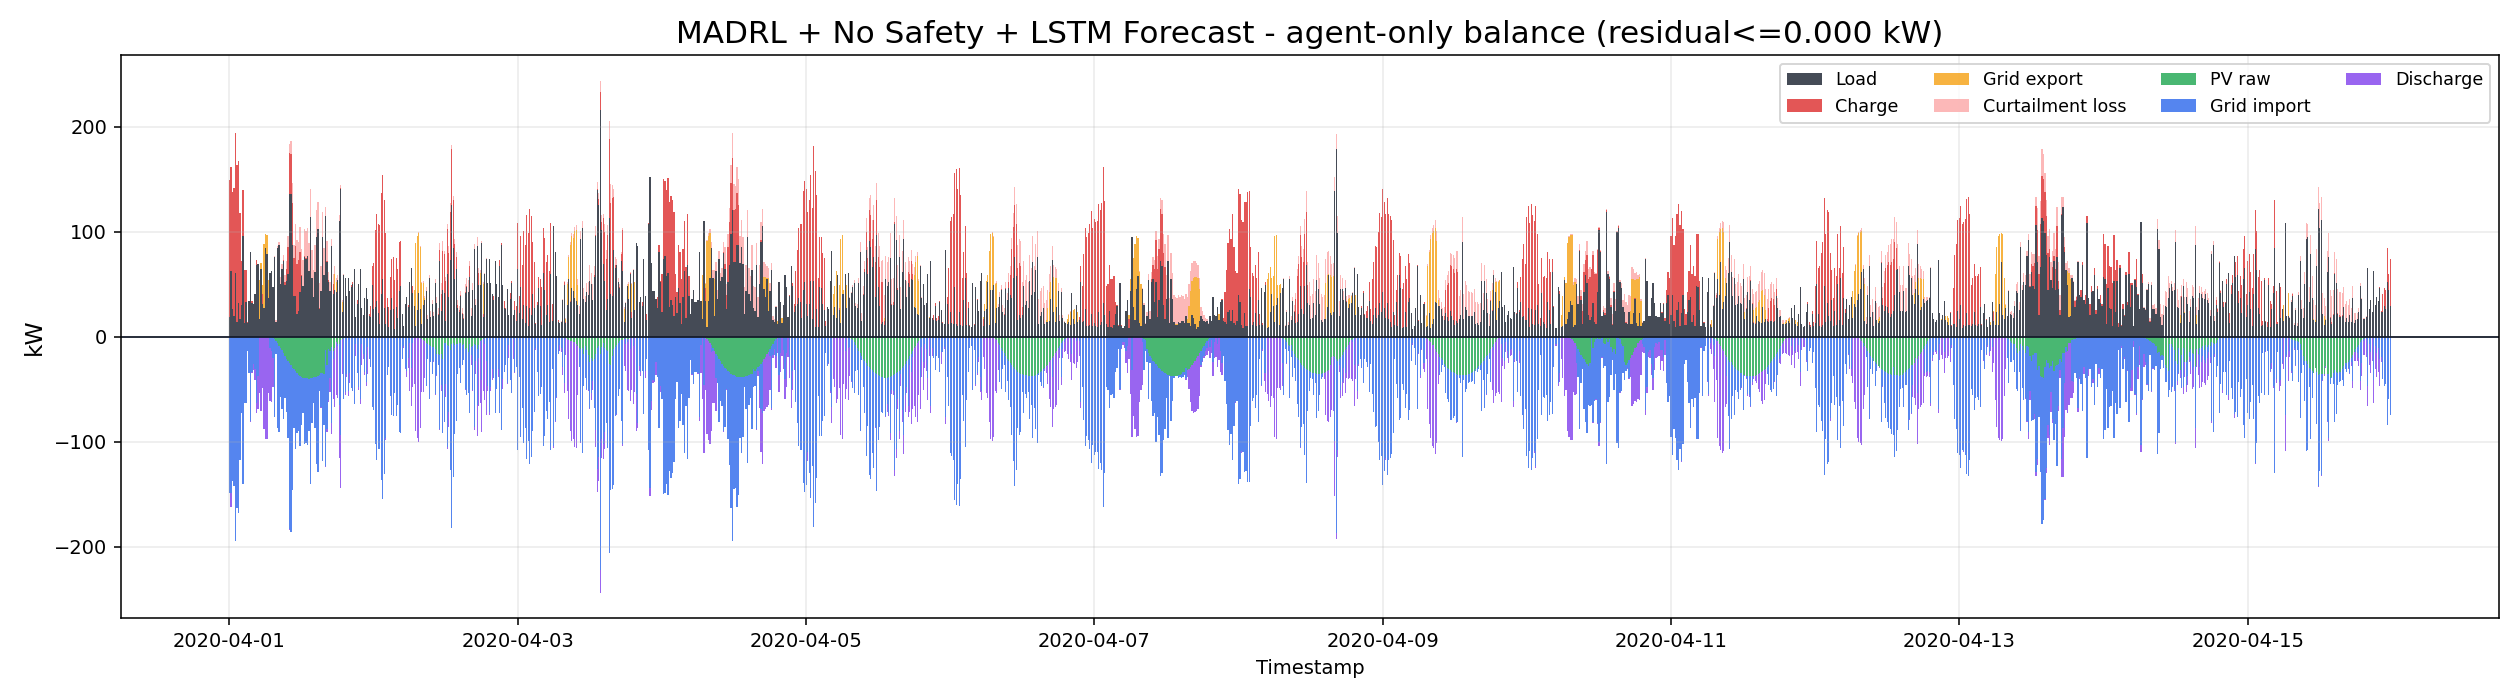

2. 电价


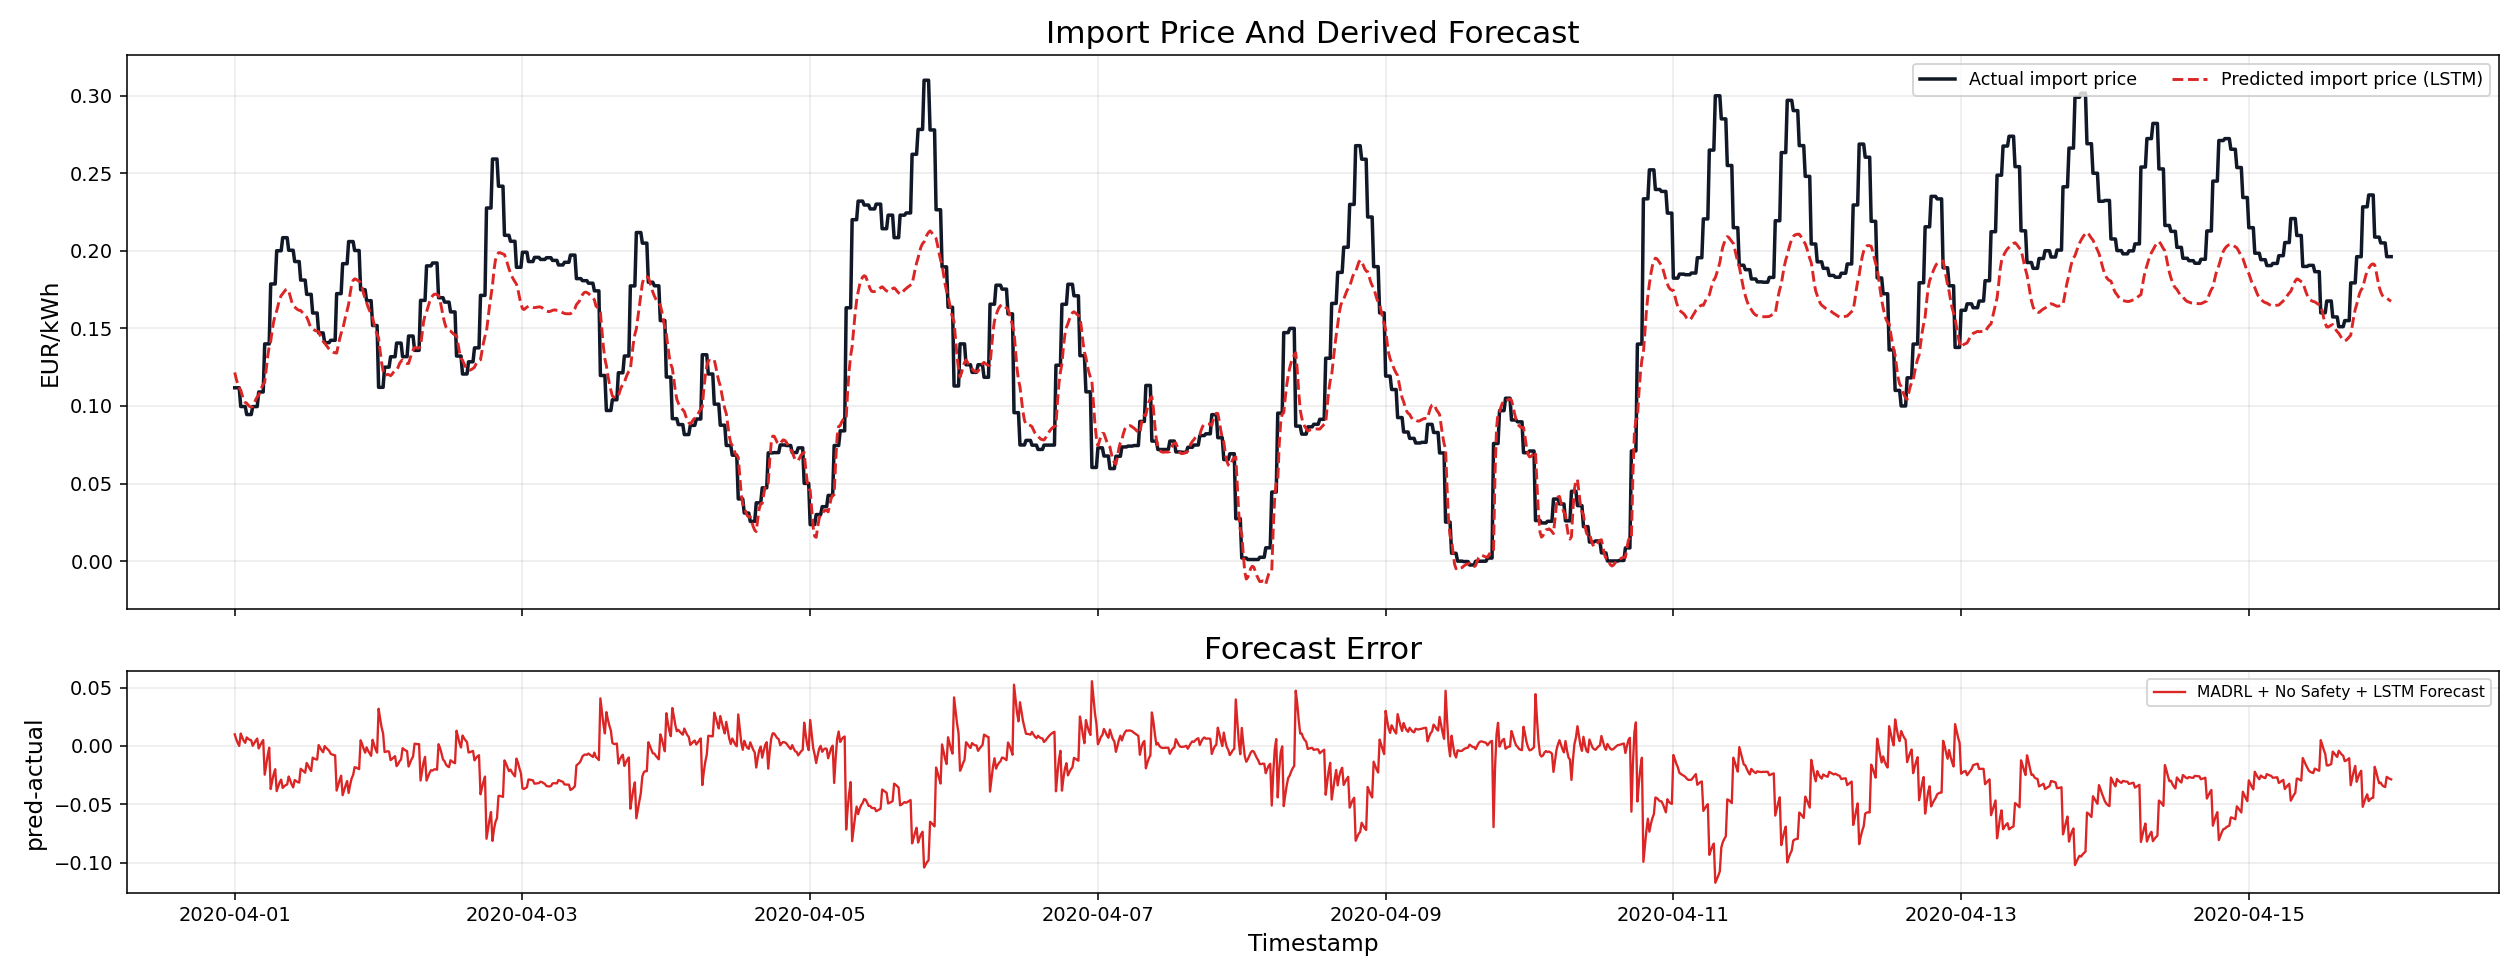

3. 总体储能充放功率与 SoC


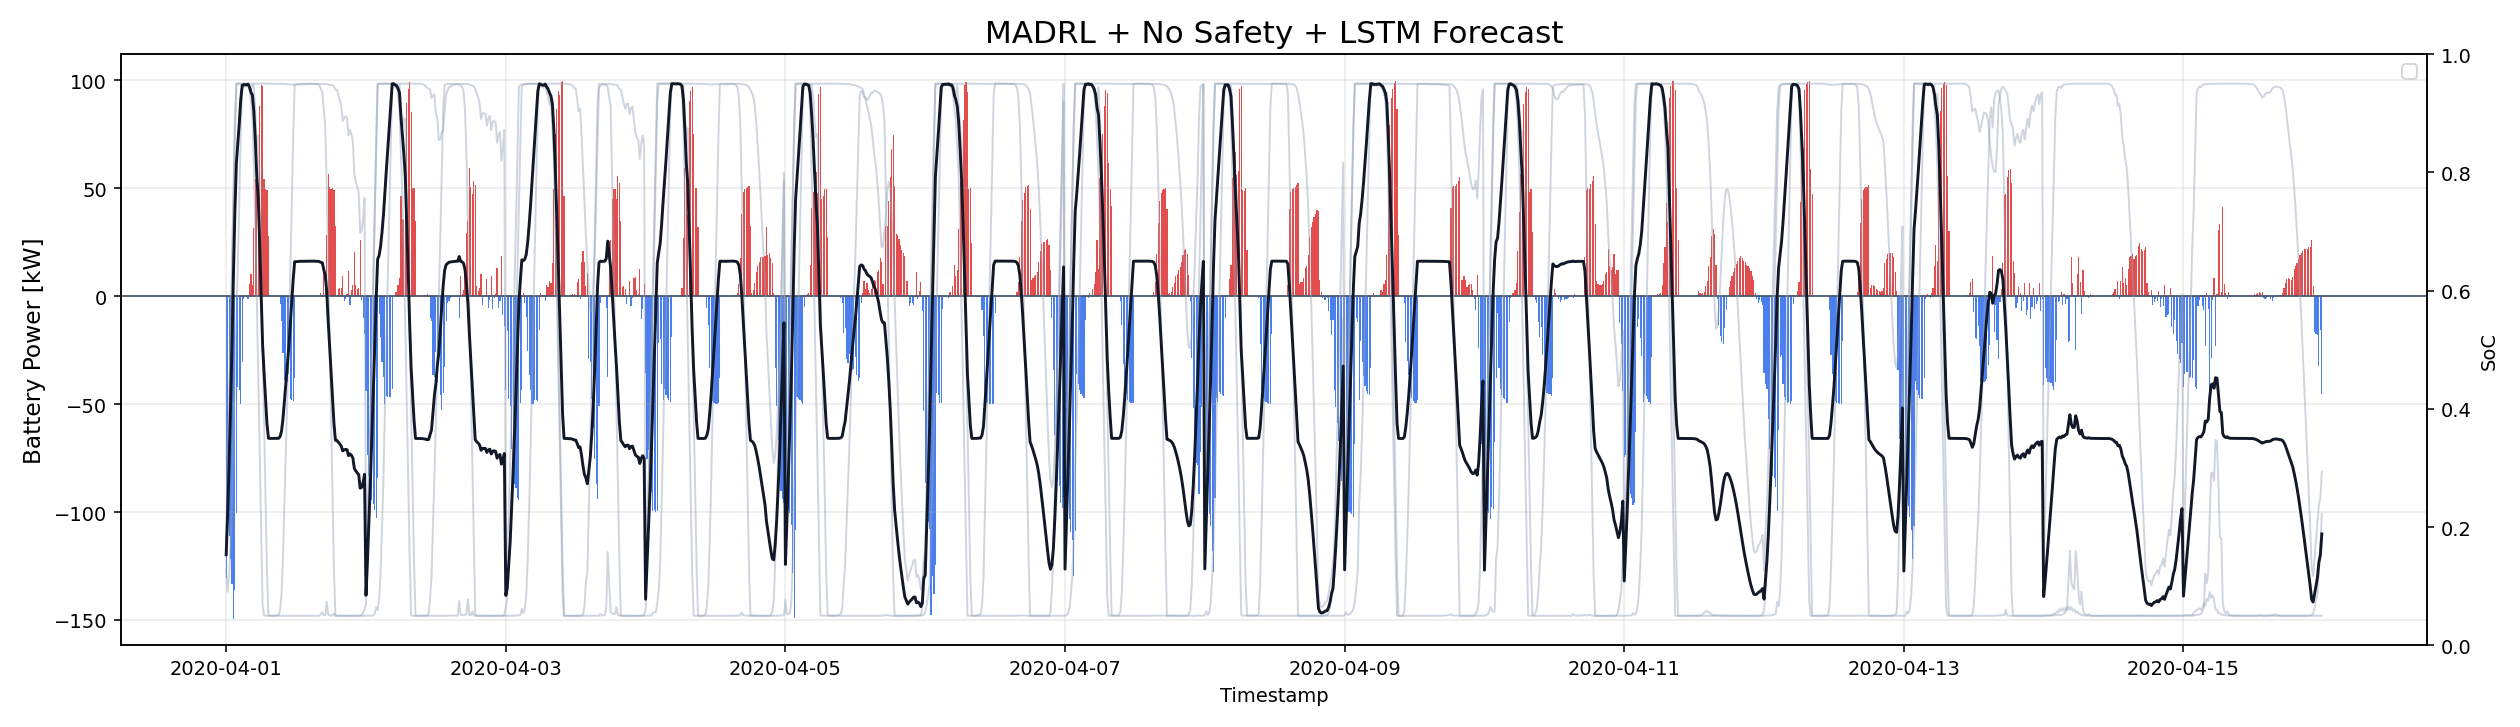

4. 电压


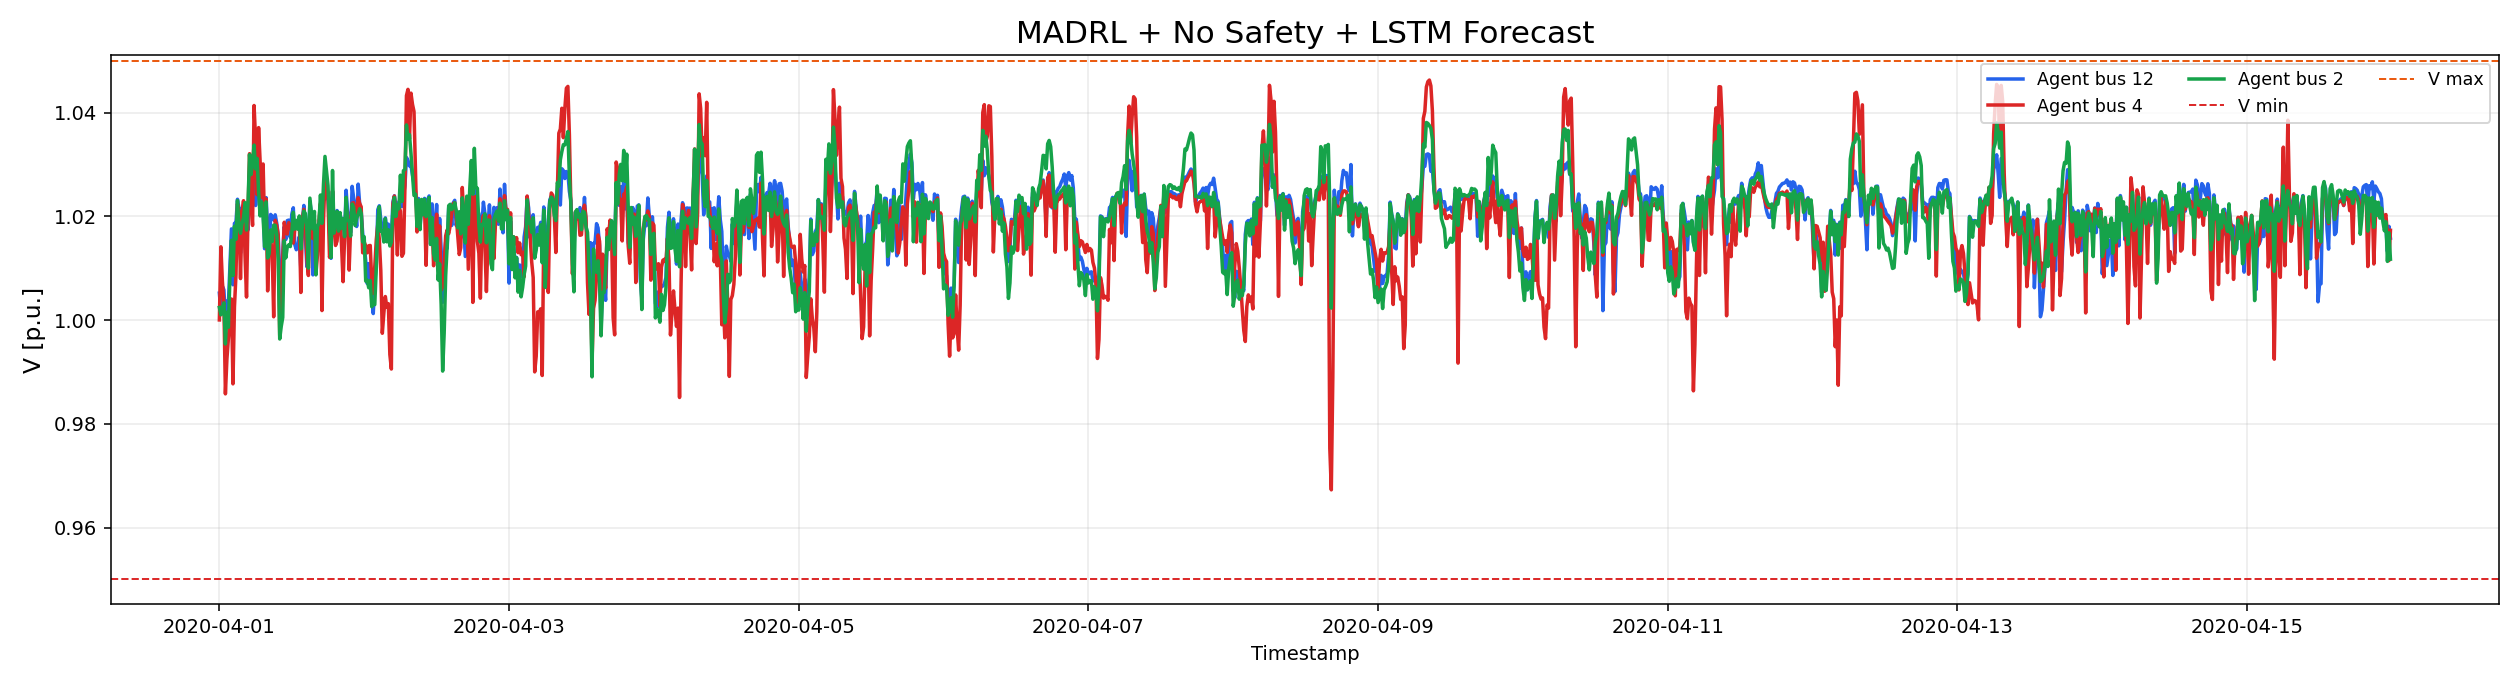

5. 净负荷


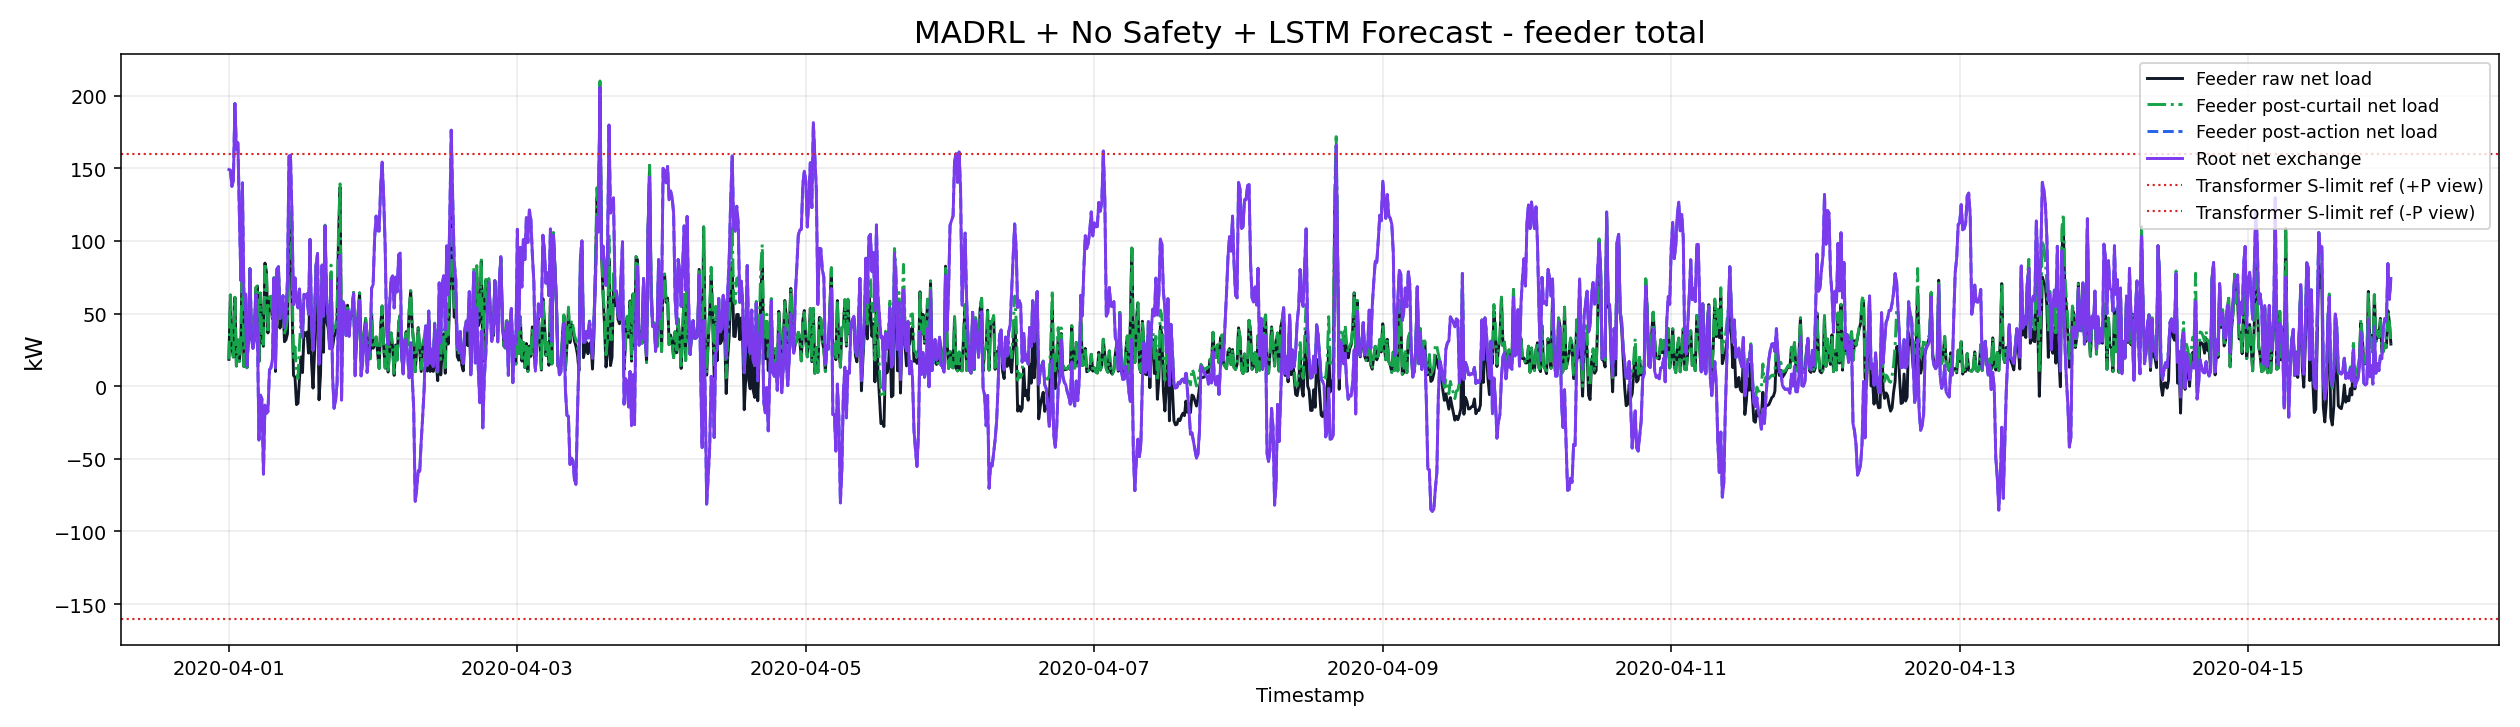

6. 训练奖励


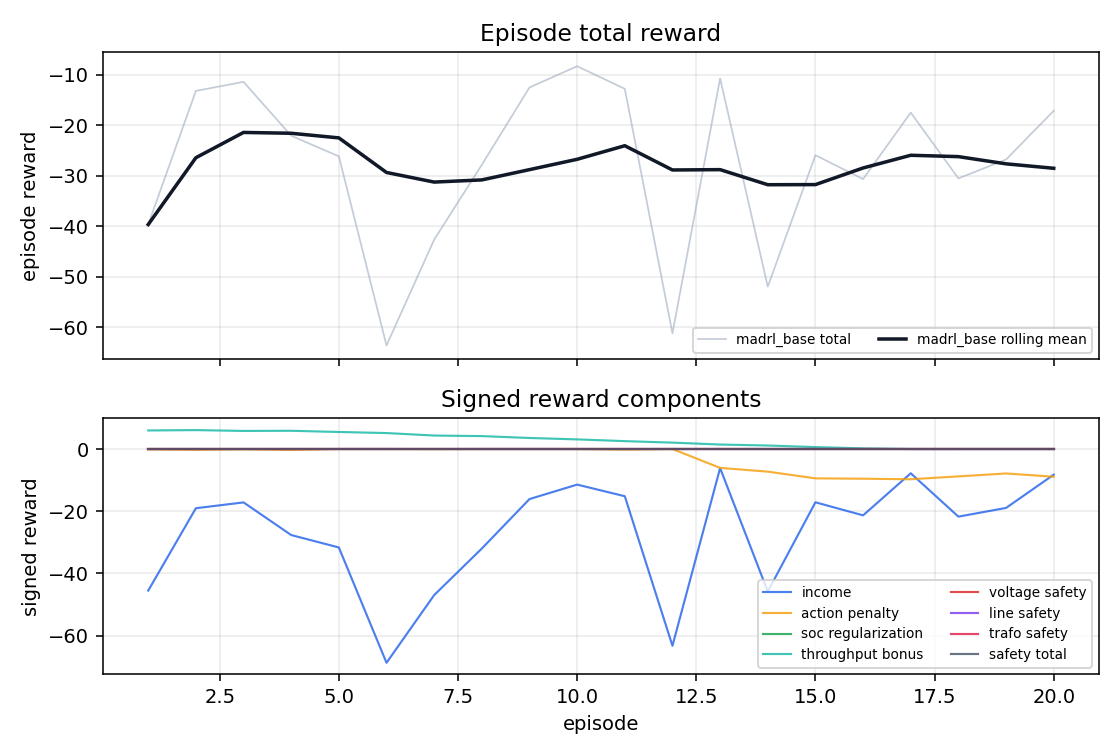

In [4]:
plt.close("all")
figures = plot_madrl_outputs(result, run_dir)
_plot_specs = [
    ("1. 电力电量平衡", "madrl_base_power_balance"),
    ("2. 电价", "madrl_base_price"),
    ("3. 总体储能充放功率与 SoC", "madrl_base_battery_soc"),
    ("4. 电压", "madrl_base_voltage"),
    ("5. 净负荷", "madrl_base_net_load"),
    ("6. 训练奖励", "madrl_base_learning_curve"),
]
for title, name in _plot_specs:
    print(title)
    display(Image(filename=str(run_dir / "figures" / f"{name}.png")))
    plt.close(figures[name])
